# Vollständige Analysestruktur (für die Verteidigung)
Der folgende Block folgt der Logik: EDA -> Statistik -> Kollinearität -> Baseline-ML -> Wichtigkeit -> Schlussfolgerung.

## 1. Laden und erste Prüfung
Ziel: Größe, Datentypen, fehlende Werte und die allgemeine Datenqualität prüfen.

In [2]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv("../data/raw/dataset.csv")

print("Form:", raw_df.shape)
display(raw_df.head())
raw_df.info()

print("\nFehlende Werte pro Spalte:")
display(raw_df.isna().sum().sort_values(ascending=False))

numeric_raw = raw_df.select_dtypes(include=["number"]).columns.tolist()
categorical_raw = [c for c in raw_df.columns if c not in numeric_raw]
print("\nNumerische Spalten:", numeric_raw)
print("Kategoriale Spalten:", categorical_raw)

Form: (9000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,154,34,795697,2022-03-30 19:28:31,IL,500/1000,998,"856,999451918663",3998347,419228,...,?,67253,11362,11390,46297,Ford,F150,1997,N,NaN
1,172,36,792268,2001-04-27 22:40:12,OH,250/500,987,"1282,38961933666",0,420170,...,NO,52481,9427,9428,33509,Accura,MDX,1980,N,NaN
2,353,47,568504,2011-12-25 09:00:46,IN,250/500,1976,"1145,49004833162",0,421251,...,?,62665,5441,11077,44771,Dodge,RAM,2010,N,NaN
3,47,37,971810,2021-12-17 10:10:11,IN,250/500,1999,"1255,26787945401",0,421620,...,NO,6614,670,667,5423,Jeep,Wrangler,1983,N,NaN
4,301,50,898345,2001-01-25 21:42:10,IL,100/300,1995,"1376,09676101069",0,421961,...,?,66431,12218,6086,48589,Volkswagen,Jetta,2036,N,NaN


<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           9000 non-null   int64  
 1   age                          9000 non-null   int64  
 2   policy_number                9000 non-null   int64  
 3   policy_bind_date             9000 non-null   str    
 4   policy_state                 9000 non-null   str    
 5   policy_csl                   9000 non-null   str    
 6   policy_deductable            9000 non-null   int64  
 7   policy_annual_premium        9000 non-null   str    
 8   umbrella_limit               9000 non-null   int64  
 9   insured_zip                  9000 non-null   int64  
 10  insured_sex                  9000 non-null   str    
 11  insured_education_level      9000 non-null   str    
 12  insured_occupation           9000 non-null   str    
 13  insured_hobbies              

_c39                           9000
fraud_reported                 1000
authorities_contacted           819
months_as_customer                0
policy_state                      0
age                               0
policy_number                     0
policy_bind_date                  0
policy_annual_premium             0
policy_deductable                 0
policy_csl                        0
umbrella_limit                    0
insured_occupation                0
insured_hobbies                   0
insured_sex                       0
insured_zip                       0
capital-gains                     0
capital-loss                      0
incident_type                     0
incident_date                     0
collision_type                    0
incident_severity                 0
insured_relationship              0
insured_education_level           0
incident_city                     0
incident_state                    0
incident_location                 0
incident_hour_of_the_day    


Numerische Spalten: ['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', '_c39']
Kategoriale Spalten: ['policy_bind_date', 'policy_state', 'policy_csl', 'policy_annual_premium', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


## 2. Bereinigung und Vorbereitung
Schritte: spezielle Missing-Werte ersetzen, Imputation, Typkonvertierung, Duplikate entfernen.

In [3]:
df_clean = raw_df.copy()

# Spezielle Kennzeichen für fehlende Werte ersetzen
df_clean = df_clean.replace("?", np.nan)

# Explizite Typ-Trennung: numerisch vs kategorial
num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Imputation: Median für numerische, Modus für kategoriale Variablen
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    if df_clean[c].isna().any():
        mode_series = df_clean[c].mode(dropna=True)
        if len(mode_series) > 0:
            df_clean[c] = df_clean[c].fillna(mode_series.iloc[0])

# Kategoriale Spalten in category umwandeln
for c in cat_cols:
    df_clean[c] = df_clean[c].astype("category")

print("Duplikate vor dem Entfernen:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Form nach der Bereinigung:", df_clean.shape)
print("Verbleibende fehlende Werte:", int(df_clean.isna().sum().sum()))

display(df_clean.head())

Duplikate vor dem Entfernen: 0
Form nach der Bereinigung: (9000, 40)
Verbleibende fehlende Werte: 9000


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,154,34,795697,2022-03-30 19:28:31,IL,500/1000,998,"856,999451918663",3998347,419228,...,NO,67253,11362,11390,46297,Ford,F150,1997,N,NaN
1,172,36,792268,2001-04-27 22:40:12,OH,250/500,987,"1282,38961933666",0,420170,...,NO,52481,9427,9428,33509,Accura,MDX,1980,N,NaN
2,353,47,568504,2011-12-25 09:00:46,IN,250/500,1976,"1145,49004833162",0,421251,...,NO,62665,5441,11077,44771,Dodge,RAM,2010,N,NaN
3,47,37,971810,2021-12-17 10:10:11,IN,250/500,1999,"1255,26787945401",0,421620,...,NO,6614,670,667,5423,Jeep,Wrangler,1983,N,NaN
4,301,50,898345,2001-01-25 21:42:10,IL,100/300,1995,"1376,09676101069",0,421961,...,NO,66431,12218,6086,48589,Volkswagen,Jetta,2036,N,NaN


## 3. Explorative Datenanalyse (EDA)
Wir betrachten die Zielvariable vehicle_claim, grundlegende Gruppierungen und Korrelationen numerischer Merkmale.

count     9000.000000
mean     37928.123222
std      18878.923565
min         69.000000
25%      30205.500000
50%      42136.500000
75%      50806.250000
max      80637.000000
Name: vehicle_claim, dtype: float64


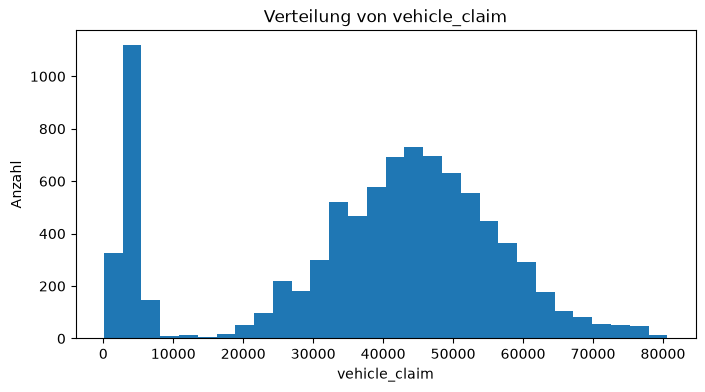

In [4]:
import matplotlib.pyplot as plt

df_clean["vehicle_claim"] = pd.to_numeric(df_clean["vehicle_claim"], errors="coerce")

print(df_clean["vehicle_claim"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df_clean["vehicle_claim"], bins=30)
plt.title("Verteilung von vehicle_claim")
plt.xlabel("vehicle_claim")
plt.ylabel("Anzahl")
plt.show()

In [5]:
display(df_clean.groupby("incident_type", observed=False)["vehicle_claim"].mean().sort_values(ascending=False))
display(df_clean.groupby("incident_severity", observed=False)["vehicle_claim"].mean().sort_values(ascending=False))

incident_type
Single Vehicle Collision    46477.492694
Multi-vehicle Collision     44157.693450
Vehicle Theft                3998.790780
Parked Car                   3806.354497
Name: vehicle_claim, dtype: float64

incident_severity
Major Damage      45937.495169
Total Loss        44804.541667
Minor Damage      34897.784369
Trivial Damage     3892.080247
Name: vehicle_claim, dtype: float64

## 4. Hauptstatistik
Kategoriale Merkmale: ANOVA + Eta-Quadrat. Numerische Merkmale: Spearman.

In [7]:
from scipy.stats import f_oneway, spearmanr

df = df_clean
target = "vehicle_claim"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Spearman (numerische Merkmale)
num_rows = []
for c in num_cols:
    part = df[[c, target]].dropna()
    if part[c].nunique() < 2:
        continue

    rho, p = spearmanr(part[c], part[target])

    num_rows.append({
        "feature": c,
        "test": "spearman",
        "effect": rho,
        "p_value": p
    })

# ANOVA + eta²
def anova_eta2(df, col, target):
    part = df[[col, target]].dropna()
    if part[col].nunique() < 2:
        return None

    groups = [g[target].values for _, g in part.groupby(col)]
    f_stat, p_val = f_oneway(*groups)

    grand_mean = part[target].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((part[target] - grand_mean) ** 2).sum()
    eta2 = ss_between / ss_total if ss_total > 0 else None

    return {
        "feature": col,
        "test": "anova",
        "effect": eta2,
        "p_value": p_val
    }

cat_rows = []
for c in cat_cols:
    if c == target:
        continue
    res = anova_eta2(df, c, target)
    if res:
        cat_rows.append(res)

stats_table = pd.DataFrame(num_rows + cat_rows)
stats_table = stats_table.sort_values("effect", ascending=False)

display(stats_table)
display(stats_table[stats_table["p_value"] < 0.05])

c:\Users\hshakademie8\InterGeeks-Agiles-Programmierprojekt\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\hshakademie8\AppData\Local\Temp\ipykernel_30920\2478663507.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*groups)
c:\Users\hshakademie8\InterGeeks-Agiles-Programmierprojekt\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\hshakademie8\AppData\Local\Temp\ipykernel_30920\2478663507.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for 

,feature,test,effect,p_value
25,incident_date,anova,1.000000,NaN
16,policy_bind_date,anova,1.000000,NaN
19,policy_annual_premium,anova,1.000000,NaN
32,incident_location,anova,0.999564,0.000000e+00
12,total_claim_amount,spearman,0.963957,0.000000e+00
26,incident_type,anova,0.706364,0.000000e+00
14,property_claim,spearman,0.692485,0.000000e+00
13,injury_claim,spearman,0.682539,0.000000e+00
28,incident_severity,anova,0.388515,0.000000e+00
29,authorities_contacted,anova,0.237165,0.000000e+00


,feature,test,effect,p_value
32,incident_location,anova,0.999564,0.000000e+00
12,total_claim_amount,spearman,0.963957,0.000000e+00
26,incident_type,anova,0.706364,0.000000e+00
14,property_claim,spearman,0.692485,0.000000e+00
13,injury_claim,spearman,0.682539,0.000000e+00
28,incident_severity,anova,0.388515,0.000000e+00
29,authorities_contacted,anova,0.237165,0.000000e+00
9,number_of_vehicles_involved,spearman,0.200697,1.954021e-82
27,collision_type,anova,0.200576,0.000000e+00
8,incident_hour_of_the_day,spearman,0.174696,1.325071e-62


## 5. Prüfung auf Multikollinearität
Wir betrachten Abhängigkeiten zwischen kategorialen Merkmalen und Korrelationen numerischer Merkmale.

In [8]:
if "incident_type" in df_clean.columns and "collision_type" in df_clean.columns:
    display(pd.crosstab(df_clean["incident_type"], df_clean["collision_type"]))

display(df_clean.corr(numeric_only=True))

collision_type,Front Collision,Rear Collision,Side Collision
incident_type,,,
Multi-vehicle Collision,1035,1368,1368
Parked Car,0,756,0
Single Vehicle Collision,1251,1260,1116
Vehicle Theft,0,846,0


,months_as_customer,age,policy_number,policy_deductable,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
months_as_customer,1.000000,0.921005,0.057167,0.027215,0.015828,0.017561,0.006237,0.019923,0.070589,0.014847,-0.010054,0.058392,0.062086,0.065801,0.034669,0.061000,-0.012662,NaN
age,0.921005,1.000000,0.060400,0.028027,0.018391,0.024554,-0.007586,0.007928,0.087182,0.022256,-0.016929,0.052182,0.070885,0.076392,0.060988,0.063647,-0.015471,NaN
policy_number,0.057167,0.060400,1.000000,-0.006483,0.009092,0.007292,0.009629,-0.005945,0.000154,0.013486,-0.004701,-0.012765,-0.017620,-0.008386,-0.010382,-0.020013,-0.004220,NaN
policy_deductable,0.027215,0.028027,-0.006483,1.000000,0.010575,0.003990,0.035441,-0.023795,0.060692,0.051283,-0.023203,0.066766,0.022548,0.039409,0.064372,0.005162,0.001583,NaN
umbrella_limit,0.015828,0.018391,0.009092,0.010575,1.000000,0.019787,-0.047409,-0.024265,-0.023293,-0.021329,0.022673,-0.006741,-0.040288,-0.045371,-0.023536,-0.038433,0.000672,NaN
insured_zip,0.017561,0.024554,0.007292,0.003990,0.019787,1.000000,0.007771,0.048894,0.007704,0.027590,0.029235,0.018704,-0.032469,-0.016004,-0.006105,-0.039566,-0.011670,NaN
capital-gains,0.006237,-0.007586,0.009629,0.035441,-0.047409,0.007771,1.000000,-0.046763,-0.016311,0.061514,0.055710,-0.017561,0.015978,0.025803,-0.000664,0.015314,-0.010395,NaN
capital-loss,0.019923,0.007928,-0.005945,-0.023795,-0.024265,0.048894,-0.046763,1.000000,-0.025219,-0.014974,-0.024429,-0.041417,-0.036370,-0.046184,-0.023289,-0.032805,-0.028570,NaN
incident_hour_of_the_day,0.070589,0.087182,0.000154,0.060692,-0.023293,0.007704,-0.016311,-0.025219,1.000000,0.120681,-0.034515,0.006764,0.217306,0.165640,0.179392,0.215846,0.014320,NaN
number_of_vehicles_involved,0.014847,0.022256,0.013486,0.051283,-0.021329,0.027590,0.061514,-0.014974,0.120681,1.000000,0.014030,-0.014669,0.274267,0.224379,0.218757,0.269329,0.001363,NaN


## 6. Schlüsselfall: incident_severity vs vehicle_claim

In [9]:
display(
    df_clean.groupby("incident_severity", observed=False)["vehicle_claim"].agg(["mean", "median", "count"])
)

groups_case = [
    g["vehicle_claim"].values
    for _, g in df_clean.groupby("incident_severity", observed=False)
]

,mean,median,count
incident_severity,,,
Major Damage,45937.495169,45563.5,2484
Minor Damage,34897.784369,40145.0,3186
Total Loss,44804.541667,45039.0,2520
Trivial Damage,3892.080247,3830.5,810


## 7. Baseline-Modell (Random Forest)
Wir bauen ein einfaches Baseline-Modell, um die prädiktive Wichtigkeit der Merkmale zu prüfen.

In [12]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ml_df = df_clean.copy()

# Erweiterter Leakage-Check: claim-nahe Komponenten entfernen
candidate_leakage = [
    c for c in ml_df.columns
    if ("claim" in c.lower()) and (c != "vehicle_claim")
]
if candidate_leakage:
    print("Entfernte potenzielle Leakage-Spalten:", candidate_leakage)
    ml_df = ml_df.drop(columns=candidate_leakage)

# One-Hot-Kodierung
ml_encoded = pd.get_dummies(ml_df, drop_first=True)

X = ml_encoded.drop("vehicle_claim", axis=1)
y = ml_encoded["vehicle_claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

print("R2 (Holdout):", r2_score(y_test, pred))
print("MAE (Holdout):", mean_absolute_error(y_test, pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf_model, X, y, cv=cv, scoring="r2", n_jobs=-1)
print("R2 (5-fold CV):", cv_r2.mean(), "+/-", cv_r2.std())

Entfernte potenzielle Leakage-Spalten: ['total_claim_amount', 'injury_claim', 'property_claim']
R2 (Holdout): 0.7612371201763092
MAE (Holdout): 6732.662611919247
R2 (5-fold CV): 0.7512037893046909 +/- 0.016569927623970315


## 8. Feature-Wichtigkeit
Wir vergleichen die Modellwichtigkeiten mit dem Ranking aus den statistischen Tests.

In [13]:
rf_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

display(rf_importance.head(15).to_frame("rf_importance"))

,rf_importance
incident_type_Parked Car,0.433496
incident_type_Vehicle Theft,0.416015
incident_severity_Trivial Damage,0.088204
incident_location_5431 3rd Ridge,0.004611
incident_location_5971 5th Hwy,0.004270
capital-loss,0.003128
incident_location_9070 Tree Ave,0.002854
incident_location_2003 Maple Hwy,0.002826
incident_location_9316 Pine Ave,0.002289
incident_location_3884 Pine Lane,0.001977


## 9. Korrelations-Heatmap (Pflicht)
Diese Visualisierung macht Multikollinearität und Signal-Cluster deutlich sichtbarer als eine reine Tabelle.

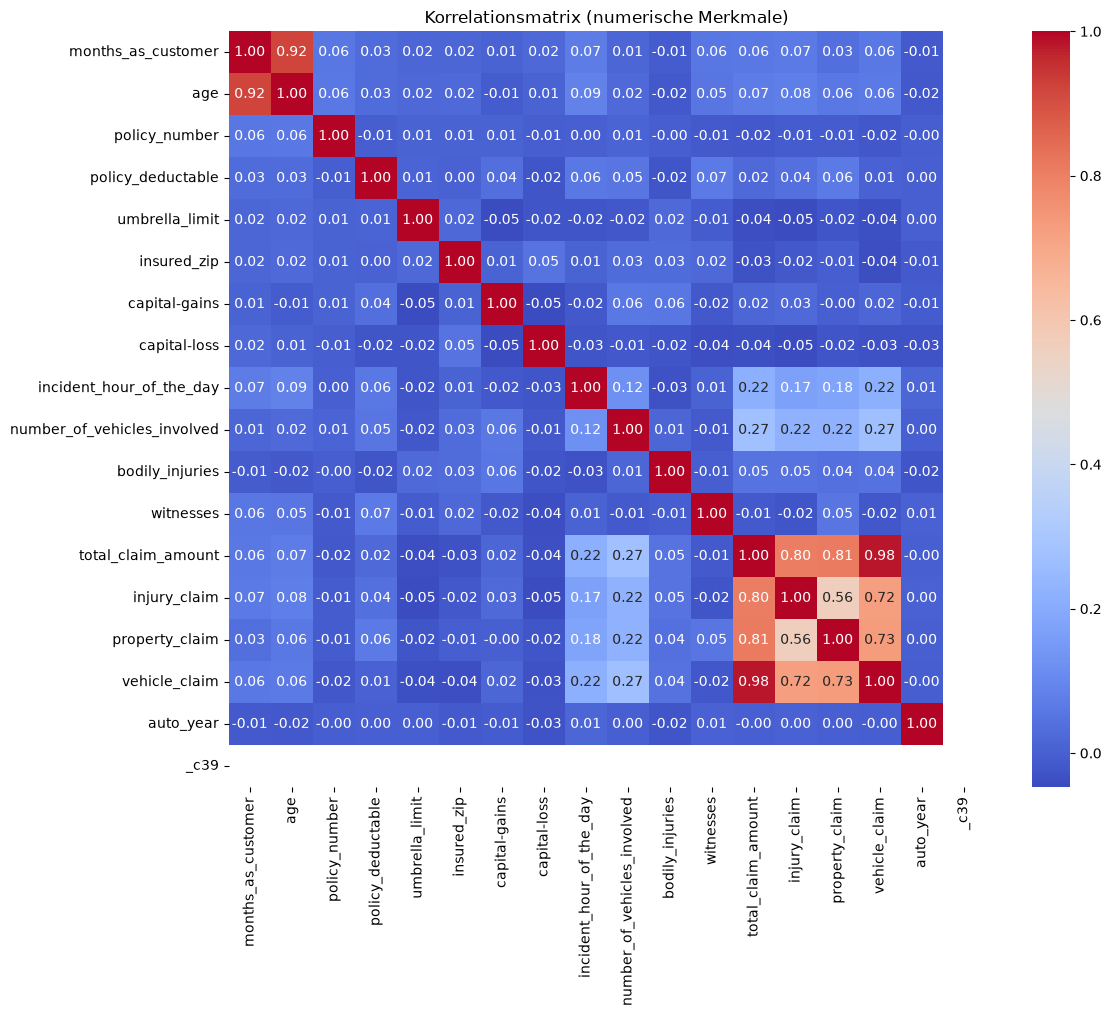

In [16]:
import seaborn as sns

corr_full = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korrelationsmatrix (numerische Merkmale)")
plt.tight_layout()
plt.show()

### Strong Final Statement
Die statistische Analyse zeigt, dass insbesondere incident_type und incident_severity den größten Einfluss auf die Höhe der Versicherungszahlung haben. Zusätzlich sind number_of_vehicles_involved, incident_hour_of_the_day und authorities_contacted signifikante Faktoren, während andere Variablen nur schwache oder instabile Zusammenhänge mit der Zielgröße aufweisen.

Der Vergleich zwischen univariater Statistik und Random-Forest-Modell bestätigt die grundlegenden Ergebnisse: Die wichtigsten Merkmale bleiben auch im Vorhersagemodell stabil. Gleichzeitig verlieren einige Variablen im multivariaten Kontext an Bedeutung, was auf überlappende Information und Multikollinearität zwischen den Einflussfaktoren zurückzuführen ist.

Insgesamt lässt sich feststellen, dass die Höhe der Versicherungszahlung hauptsächlich durch Merkmale des Unfallgeschehens bestimmt wird, während Kontextvariablen eine deutlich geringere Rolle spielen.